# Ice Cream Sales vs. Temperature Analysis

**Goal:** Investigate whether there is a relationship between temperature and ice cream sales.

- **H₀:** There is no relationship between temperature and ice cream sales.  
- **H₁:** There is a relationship between temperature and ice cream sales.

We'll use a **one-way ANOVA** test, grouping sales data by temperature bins and checking whether mean sales differ significantly across groups.

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from google.colab import files
uploaded = files.upload()

Saving blaban (1).csv to blaban (1) (1).csv


In [23]:
df = pd.read_csv("blaban (1).csv")
df.head()

,Transaction_ID,Date_Time,Branch,Product_Name,Size,Unit_Price,Quantity,Discount_Rate,Topping_Type,Customer_ID,...,Temperature_Celsius,Humidity_Percent,Store_Rating,Is_Public_Holiday,Category,Region,Is_Weekend,Hour_of_Day,Tax_Amount,Total_Sales
0,106253,2024-03-06 03:00:00,Alex-Stanly,Sweet Koshary Mix,Small,175.65,9,0.05,NaN,69698,...,22.8,88.7,1.0,0,Signature,Alexandria,0,3,221.32,1723.13
1,104685,2024-02-18 19:00:00,Cairo-Zamalek,Super B.Laban,Large,67.31,9,0.00,Nuts,89206,...,33.9,20.5,NaN,0,Signature,Greater Cairo,1,19,84.81,690.60
2,101732,2024-01-19 00:45:00,Alex-Stanly,Sweet Koshary Mix,Medium,178.51,2,0.15,Nutella,71726,...,40.9,77.0,4.0,0,Signature,Alexandria,1,0,49.98,353.45
3,104743,2024-02-19 09:30:00,Giza-Zayed,Om Ali Cream,Large,57.95,10,0.00,NaN,74303,...,28.3,38.0,1.0,0,Traditional,Greater Cairo,0,9,81.13,660.63
4,104522,2024-02-17 02:15:00,Dubai-Marina,Rice Pudding Nuts,Large,89.67,4,0.00,Nutella,85273,...,27.5,29.4,5.0,0,Traditional,UAE,1,2,50.22,408.90


## Exploratory Plot: Sales by Temperature Bin (Before Any Adjustments)

Before cleaning or merging bins, let's first look at total ice cream sales across raw 5-degree temperature bins to get a sense of the distribution.

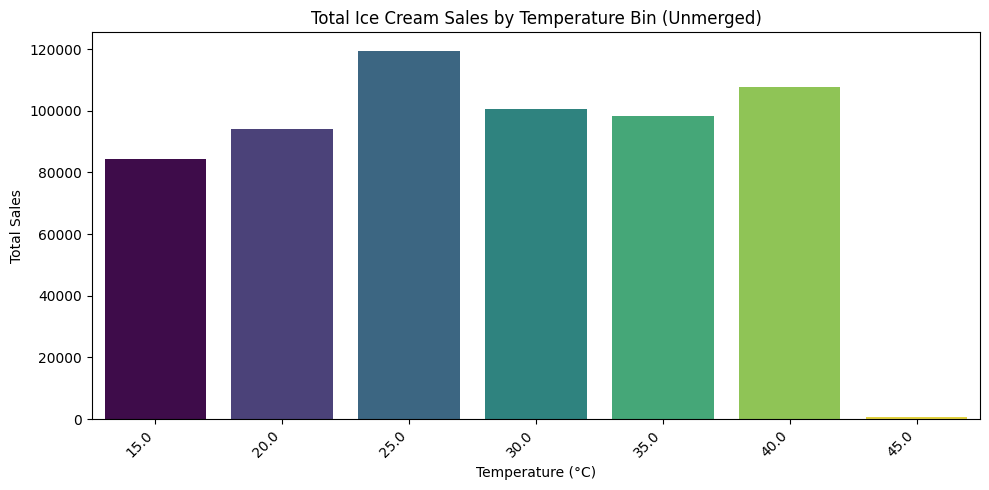

In [24]:
# Filter for ice cream only
df_ice = df[df['Category'] == 'Ice Cream'].copy()

# Bin temperatures into 5-degree intervals
df_ice['Temperature_Bin'] = (df_ice['Temperature_Celsius'] // 5) * 5

# Total sales per bin
sales_by_bin_raw = df_ice.groupby('Temperature_Bin')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Temperature_Bin', y='Total_Sales', data=sales_by_bin_raw,
            hue='Temperature_Bin', legend=False, palette='viridis')
plt.title('Total Ice Cream Sales by Temperature Bin (Unmerged)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Preparation: Average Daily Sales per Bin

Looking at total sales per bin can be misleading — some temperature ranges simply have more days recorded than others. To make a fair comparison, we calculate **average daily sales** per bin.

Also, the 45°C bin has very few observations, so we merge it into the 40°C bin to avoid unreliable group estimates.

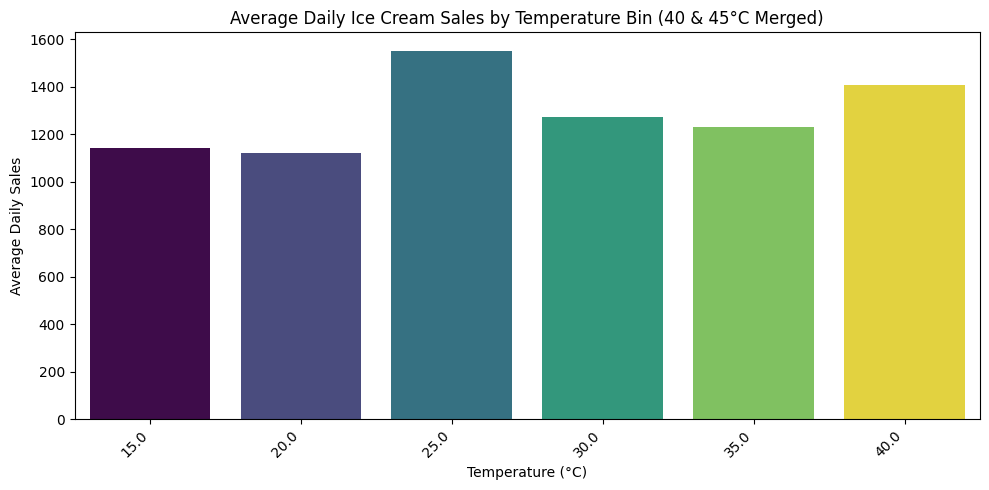

In [25]:
df_ice_clean = df[df['Category'] == 'Ice Cream'].copy()

# Extract date from datetime
df_ice_clean['Date'] = pd.to_datetime(df_ice_clean['Date_Time']).dt.date

# Create 5-degree bins
df_ice_clean['Temperature_Bin'] = (df_ice_clean['Temperature_Celsius'] // 5) * 5

# Merge the sparse 45°C bin into 40°C
df_ice_clean.loc[df_ice_clean['Temperature_Bin'] == 45, 'Temperature_Bin'] = 40

# Total sales per bin
sales_by_bin = df_ice_clean.groupby('Temperature_Bin')['Total_Sales'].sum().reset_index()

# Count unique days per bin (to normalize)
days_per_bin = df_ice_clean.groupby('Temperature_Bin')['Date'].nunique().reset_index()
days_per_bin.rename(columns={'Date': 'Number_of_Days'}, inplace=True)

# Merge and calculate average daily sales
sales_by_bin = pd.merge(sales_by_bin, days_per_bin, on='Temperature_Bin', how='left')
sales_by_bin['Average_Daily_Sales'] = sales_by_bin['Total_Sales'] / sales_by_bin['Number_of_Days']

plt.figure(figsize=(10, 5))
sns.barplot(x='Temperature_Bin', y='Average_Daily_Sales', data=sales_by_bin,
            hue='Temperature_Bin', legend=False, palette='viridis')
plt.title('Average Daily Ice Cream Sales by Temperature Bin (40 & 45°C Merged)')
plt.xlabel('Temperature (°C)')
plt.ylabel('Average Daily Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Statistical Test: One-Way ANOVA

We use a **one-way ANOVA** to test whether average ice cream sales differ significantly across temperature bins.

- Each temperature bin is treated as a group.
- We compare the variance *between* groups to the variance *within* groups.
- If sales are unrelated to temperature, we'd expect no meaningful difference across bins.

In [26]:
# Group sales values by temperature bin
temp_bins = df_ice_clean['Temperature_Bin'].unique()
groups = [df_ice_clean['Total_Sales'][df_ice_clean['Temperature_Bin'] == b] for b in temp_bins]

# Run one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

F-statistic: 1.7246
P-value:     0.1264


## Conclusion

With a p-value of **0.12**, which is greater than our significance level of **0.05**, we **fail to reject the null hypothesis**.

This means the data does not provide sufficient evidence to conclude that temperature has a significant effect on ice cream sales at the 95% confidence level.

# **Now we test if weekends have any effect on sales**
H₀: There is no relationship between weekend/weekday and ice cream sales (μ_weekday = μ_weekend)

H₁: There is a relationship between weekend/weekday and ice cream sales (μ_weekday ≠ μ_weekend)

In [27]:

df_ice_clean['Day_of_Week'] = pd.to_datetime(df_ice_clean['Date_Time']).dt.dayofweek
df_ice_clean['is_weekend'] = df_ice_clean['Day_of_Week'].isin([5, 6]).astype(int)

sales_weekday = df_ice_clean[df_ice_clean['is_weekend'] == 0]['Total_Sales']
sales_weekend = df_ice_clean[df_ice_clean['is_weekend'] == 1]['Total_Sales']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(sales_weekday, sales_weekend)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

T-statistic: 0.1667
P-value:     0.8676


/tmp/ipykernel_5689/1911288686.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_weekend', y='Total_Sales', data=df_ice_clean, palette='pastel')


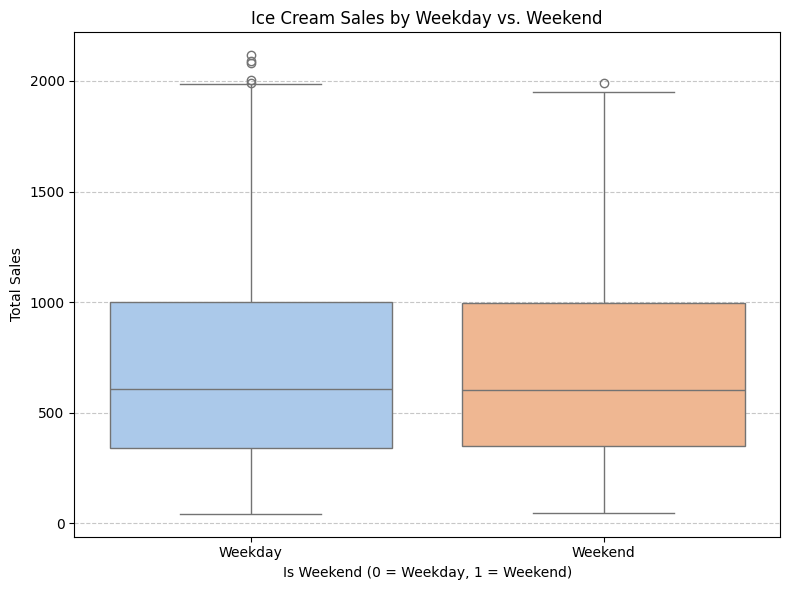

In [28]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_weekend', y='Total_Sales', data=df_ice_clean, palette='pastel')
plt.title('Ice Cream Sales by Weekday vs. Weekend')
plt.xlabel('Is Weekend (0 = Weekday, 1 = Weekend)')
plt.ylabel('Total Sales')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusion (Weekend Analysis)

Based on the p-value from the independent samples t-test, we will determine if there is a statistically significant difference in ice cream sales between weekdays and weekends. A p-value less than our significance level would lead us to reject the null hypothesis, suggesting a relationship between weekends and ice cream sales.

##--> Reject null hypothesis